In [ ]:
import pandas as pd
from methyldl.data.utils import count_unique_positions

In [18]:
path_chr1 = "../Data/Curated/rrms_dmrs_only_mincov40_corrected/chr20/train.parquet"
path_chr2 = "../Data/Curated/rrms_dmrs_only_mincov40_corrected/chr12/train.parquet"

In [19]:
chr1 = pd.read_parquet(path_chr1)
chr2 = pd.read_parquet(path_chr2)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import seaborn as sns
from scipy import stats
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

# Set style for better plots
plt.style.use("default")
# sns.set_palette("husl")


class MultiomicsEDA:
    def __init__(self, chr1_data, chr2_data):
        """
        Initialize EDA class with chr1 and chr2 datasets

        Args:
            chr1_data: DataFrame with chr1 reads
            chr2_data: DataFrame with chr2 reads
        """
        self.chr1 = chr1_data.copy()
        self.chr2 = chr2_data.copy()

        # Add chromosome identifier for combined analysis
        self.chr1["chromosome_label"] = "chr1"
        self.chr2["chromosome_label"] = "chr2"

        # Combine datasets for comparative analysis
        self.combined = pd.concat([self.chr1, self.chr2], ignore_index=True)

        print(f"Chr1 dataset: {len(self.chr1)} reads")
        print(f"Chr2 dataset: {len(self.chr2)} reads")
        print(f"Combined dataset: {len(self.combined)} reads")

    def basic_statistics(self):
        """Generate basic statistics comparison"""
        print("\n" + "=" * 60)
        print("BASIC STATISTICS COMPARISON")
        print("=" * 60)

        # Key numerical features for analysis
        numerical_features = [
            "read_length",
            "sequence_length",
            "total_cpgs",
            "methylated_cpgs",
            "unmethylated_cpgs",
            "methylation_rate",
            "mapping_quality",
            "overlapping_dmrs_bps",
            "sum_abs_areastat",
            "max_dmr_overlap_percentage",
            "mean_methy_diff",
            "total_dmr_ncg",
            "coverage",
        ]

        stats_comparison = pd.DataFrame()

        for feature in numerical_features:
            if feature in self.chr1.columns and feature in self.chr2.columns:
                chr1_stats = {
                    "chr1_mean": self.chr1[feature].mean(),
                    "chr1_std": self.chr1[feature].std(),
                    "chr1_median": self.chr1[feature].median(),
                    "chr1_min": self.chr1[feature].min(),
                    "chr1_max": self.chr1[feature].max(),
                }

                chr2_stats = {
                    "chr2_mean": self.chr2[feature].mean(),
                    "chr2_std": self.chr2[feature].std(),
                    "chr2_median": self.chr2[feature].median(),
                    "chr2_min": self.chr2[feature].min(),
                    "chr2_max": self.chr2[feature].max(),
                }

                # Statistical test for difference
                stat, p_value = stats.mannwhitneyu(
                    self.chr1[feature].dropna(),
                    self.chr2[feature].dropna(),
                    alternative="two-sided",
                )

                feature_stats = {**chr1_stats, **chr2_stats, "p_value": p_value}
                stats_comparison[feature] = feature_stats

        print(stats_comparison.T.round(4))
        return stats_comparison.T

    def class_distribution_analysis(self):
        """Analyze class distribution differences"""
        print("/n" + "=" * 60)
        print("CLASS DISTRIBUTION ANALYSIS")
        print("=" * 60)

        # Overall class distribution
        chr1_dist = self.chr1["label"].value_counts(normalize=True)
        chr2_dist = self.chr2["label"].value_counts(normalize=True)

        print("Chr1 class distribution:")
        print(chr1_dist)
        print(f"Chr1 class balance ratio: {chr1_dist.min():.3f}")

        print("/nChr2 class distribution:")
        print(chr2_dist)
        print(f"Chr2 class balance ratio: {chr2_dist.min():.3f}")

        # Visualize class distribution
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        chr1_dist.plot(kind="bar", ax=axes[0], title="Chr1 Class Distribution")
        axes[0].set_ylabel("Proportion")
        axes[0].set_xlabel("Label (0=Normal, 1=Tumor)")

        chr2_dist.plot(kind="bar", ax=axes[1], title="Chr2 Class Distribution")
        axes[1].set_ylabel("Proportion")
        axes[1].set_xlabel("Label (0=Normal, 1=Tumor)")

        plt.tight_layout()
        plt.show()

        return chr1_dist, chr2_dist

    def sequence_analysis(self):
        """Analyze sequence characteristics"""
        print("/n" + "=" * 60)
        print("SEQUENCE CHARACTERISTICS ANALYSIS")
        print("=" * 60)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Sequence length distribution
        axes[0, 0].hist(
            self.chr1["sequence_length"], bins=50, alpha=0.7, label="Chr1", density=True
        )
        axes[0, 0].hist(
            self.chr2["sequence_length"], bins=50, alpha=0.7, label="Chr2", density=True
        )
        axes[0, 0].set_title("Sequence Length Distribution")
        axes[0, 0].set_xlabel("Sequence Length")
        axes[0, 0].legend()

        # Read length distribution
        axes[0, 1].hist(
            self.chr1["read_length"], bins=50, alpha=0.7, label="Chr1", density=True
        )
        axes[0, 1].hist(
            self.chr2["read_length"], bins=50, alpha=0.7, label="Chr2", density=True
        )
        axes[0, 1].set_title("Read Length Distribution")
        axes[0, 1].set_xlabel("Read Length")
        axes[0, 1].legend()

        # Mapping quality
        axes[0, 2].hist(
            self.chr1["mapping_quality"], bins=30, alpha=0.7, label="Chr1", density=True
        )
        axes[0, 2].hist(
            self.chr2["mapping_quality"], bins=30, alpha=0.7, label="Chr2", density=True
        )
        axes[0, 2].set_title("Mapping Quality Distribution")
        axes[0, 2].set_xlabel("Mapping Quality")
        axes[0, 2].legend()

        # Coverage distribution
        axes[1, 0].hist(
            self.chr1["coverage"], bins=50, alpha=0.7, label="Chr1", density=True
        )
        axes[1, 0].hist(
            self.chr2["coverage"], bins=50, alpha=0.7, label="Chr2", density=True
        )
        axes[1, 0].set_title("Coverage Distribution")
        axes[1, 0].set_xlabel("Coverage")
        axes[1, 0].legend()

        # Sequence length vs Read length scatter
        axes[1, 1].scatter(
            self.chr1["read_length"],
            self.chr1["sequence_length"],
            alpha=0.5,
            label="Chr1",
            s=1,
        )
        axes[1, 1].scatter(
            self.chr2["read_length"],
            self.chr2["sequence_length"],
            alpha=0.5,
            label="Chr2",
            s=1,
        )
        axes[1, 1].set_title("Read Length vs Sequence Length")
        axes[1, 1].set_xlabel("Read Length")
        axes[1, 1].set_ylabel("Sequence Length")
        axes[1, 1].legend()

        # Truncation impact analysis (1000bp threshold)
        chr1_truncated = (self.chr1["sequence_length"] > 1000).sum()
        chr2_truncated = (self.chr2["sequence_length"] > 1000).sum()

        truncation_data = pd.DataFrame(
            {
                "Chromosome": ["Chr1", "Chr2"],
                "Total_Reads": [len(self.chr1), len(self.chr2)],
                "Truncated_Reads": [chr1_truncated, chr2_truncated],
                "Truncation_Rate": [
                    chr1_truncated / len(self.chr1),
                    chr2_truncated / len(self.chr2),
                ],
            }
        )

        axes[1, 2].bar(
            truncation_data["Chromosome"], truncation_data["Truncation_Rate"]
        )
        axes[1, 2].set_title("Sequence Truncation Rate (>1000bp)")
        axes[1, 2].set_ylabel("Proportion Truncated")

        plt.tight_layout()
        plt.show()

        print("Truncation Analysis:")
        print(truncation_data)

        return truncation_data

    def methylation_analysis(self):
        """Analyze methylation patterns"""
        print("\n" + "=" * 60)
        print("METHYLATION PATTERN ANALYSIS")
        print("=" * 60)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # CpG sites distribution
        axes[0, 0].hist(
            self.chr1["total_cpgs"], bins=50, alpha=0.7, label="Chr1", density=True
        )
        axes[0, 0].hist(
            self.chr2["total_cpgs"], bins=50, alpha=0.7, label="Chr2", density=True
        )
        axes[0, 0].set_title("Total CpG Sites Distribution")
        axes[0, 0].set_xlabel("Total CpGs")
        axes[0, 0].legend()

        # Methylation rate distribution
        axes[0, 1].hist(
            self.chr1["methylation_rate"],
            bins=50,
            alpha=0.7,
            label="Chr1",
            density=True,
        )
        axes[0, 1].hist(
            self.chr2["methylation_rate"],
            bins=50,
            alpha=0.7,
            label="Chr2",
            density=True,
        )
        axes[0, 1].set_title("Methylation Rate Distribution")
        axes[0, 1].set_xlabel("Methylation Rate")
        axes[0, 1].legend()

        # Methylated vs Unmethylated CpGs
        axes[0, 2].scatter(
            self.chr1["methylated_cpgs"],
            self.chr1["unmethylated_cpgs"],
            alpha=0.5,
            label="Chr1",
            s=1,
        )
        axes[0, 2].scatter(
            self.chr2["methylated_cpgs"],
            self.chr2["unmethylated_cpgs"],
            alpha=0.5,
            label="Chr2",
            s=1,
        )
        axes[0, 2].set_title("Methylated vs Unmethylated CpGs")
        axes[0, 2].set_xlabel("Methylated CpGs")
        axes[0, 2].set_ylabel("Unmethylated CpGs")
        axes[0, 2].legend()

        # Methylation rate by class
        chr1_normal = self.chr1[self.chr1["label"] == 0]["methylation_rate"]
        chr1_tumor = self.chr1[self.chr1["label"] == 1]["methylation_rate"]
        chr2_normal = self.chr2[self.chr2["label"] == 0]["methylation_rate"]
        chr2_tumor = self.chr2[self.chr2["label"] == 1]["methylation_rate"]

        axes[1, 0].hist(
            [chr1_normal, chr1_tumor],
            bins=30,
            alpha=0.7,
            label=["Chr1 Normal", "Chr1 Tumor"],
            density=True,
        )
        axes[1, 0].set_title("Chr1 Methylation Rate by Class")
        axes[1, 0].set_xlabel("Methylation Rate")
        axes[1, 0].legend()

        axes[1, 1].hist(
            [chr2_normal, chr2_tumor],
            bins=30,
            alpha=0.7,
            label=["Chr2 Normal", "Chr2 Tumor"],
            density=True,
        )
        axes[1, 1].set_title("Chr2 Methylation Rate by Class")
        axes[1, 1].set_xlabel("Methylation Rate")
        axes[1, 1].legend()

        # Mean methylation difference
        axes[1, 2].hist(
            self.chr1["mean_methy_diff"], bins=50, alpha=0.7, label="Chr1", density=True
        )
        axes[1, 2].hist(
            self.chr2["mean_methy_diff"], bins=50, alpha=0.7, label="Chr2", density=True
        )
        axes[1, 2].set_title("Mean Methylation Difference Distribution")
        axes[1, 2].set_xlabel("Mean Methylation Difference")
        axes[1, 2].legend()

        plt.tight_layout()
        plt.show()

        # Statistical tests for methylation differences
        print("Methylation Rate Statistics:")
        print(
            f"Chr1 Normal vs Tumor p-value: {stats.mannwhitneyu(chr1_normal, chr1_tumor)[1]:.2e}"
        )
        print(
            f"Chr2 Normal vs Tumor p-value: {stats.mannwhitneyu(chr2_normal, chr2_tumor)[1]:.2e}"
        )

    def dmr_analysis(self):
        """Analyze DMR (Differentially Methylated Regions) characteristics"""
        print("\n" + "=" * 60)
        print("DMR CHARACTERISTICS ANALYSIS")
        print("=" * 60)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # DMR overlap percentage
        axes[0, 0].hist(
            self.chr1["max_dmr_overlap_percentage"],
            bins=50,
            alpha=0.7,
            label="Chr1",
            density=True,
        )
        axes[0, 0].hist(
            self.chr2["max_dmr_overlap_percentage"],
            bins=50,
            alpha=0.7,
            label="Chr2",
            density=True,
        )
        axes[0, 0].set_title("Max DMR Overlap Percentage")
        axes[0, 0].set_xlabel("Overlap Percentage")
        axes[0, 0].legend()

        # DMR overlap base pairs
        axes[0, 1].hist(
            self.chr1["overlapping_dmrs_bps"],
            bins=50,
            alpha=0.7,
            label="Chr1",
            density=True,
        )
        axes[0, 1].hist(
            self.chr2["overlapping_dmrs_bps"],
            bins=50,
            alpha=0.7,
            label="Chr2",
            density=True,
        )
        axes[0, 1].set_title("Overlapping DMR Base Pairs")
        axes[0, 1].set_xlabel("Base Pairs")
        axes[0, 1].legend()

        # Sum absolute area statistic
        axes[0, 2].hist(
            np.log10(self.chr1["sum_abs_areastat"] + 1),
            bins=50,
            alpha=0.7,
            label="Chr1",
            density=True,
        )
        axes[0, 2].hist(
            np.log10(self.chr2["sum_abs_areastat"] + 1),
            bins=50,
            alpha=0.7,
            label="Chr2",
            density=True,
        )
        axes[0, 2].set_title("Sum Absolute Area Statistic (log10)")
        axes[0, 2].set_xlabel("Log10(Sum Abs Area Stat + 1)")
        axes[0, 2].legend()

        # Total DMR NCG
        axes[1, 0].hist(
            np.log10(self.chr1["total_dmr_ncg"] + 1),
            bins=50,
            alpha=0.7,
            label="Chr1",
            density=True,
        )
        axes[1, 0].hist(
            np.log10(self.chr2["total_dmr_ncg"] + 1),
            bins=50,
            alpha=0.7,
            label="Chr2",
            density=True,
        )
        axes[1, 0].set_title("Total DMR NCG (log10)")
        axes[1, 0].set_xlabel("Log10(Total DMR NCG + 1)")
        axes[1, 0].legend()

        # DMR types analysis
        chr1_dmr_types = []
        chr2_dmr_types = []

        for dmr_list in self.chr1["dmr_types"]:
            if isinstance(dmr_list, list):
                chr1_dmr_types.extend(dmr_list)

        for dmr_list in self.chr2["dmr_types"]:
            if isinstance(dmr_list, list):
                chr2_dmr_types.extend(dmr_list)

        chr1_dmr_counts = Counter(chr1_dmr_types)
        chr2_dmr_counts = Counter(chr2_dmr_types)

        # Plot DMR types
        dmr_types = list(
            set(list(chr1_dmr_counts.keys()) + list(chr2_dmr_counts.keys()))
        )
        chr1_counts = [chr1_dmr_counts.get(dmr, 0) for dmr in dmr_types]
        chr2_counts = [chr2_dmr_counts.get(dmr, 0) for dmr in dmr_types]

        x = np.arange(len(dmr_types))
        width = 0.35

        axes[1, 1].bar(x - width / 2, chr1_counts, width, label="Chr1", alpha=0.7)
        axes[1, 1].bar(x + width / 2, chr2_counts, width, label="Chr2", alpha=0.7)
        axes[1, 1].set_title("DMR Types Distribution")
        axes[1, 1].set_xlabel("DMR Type")
        axes[1, 1].set_ylabel("Count")
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(dmr_types, rotation=45)
        axes[1, 1].legend()

        # DMR overlap vs methylation rate
        axes[1, 2].scatter(
            self.chr1["max_dmr_overlap_percentage"],
            self.chr1["methylation_rate"],
            alpha=0.5,
            label="Chr1",
            s=1,
        )
        axes[1, 2].scatter(
            self.chr2["max_dmr_overlap_percentage"],
            self.chr2["methylation_rate"],
            alpha=0.5,
            label="Chr2",
            s=1,
        )
        axes[1, 2].set_title("DMR Overlap vs Methylation Rate")
        axes[1, 2].set_xlabel("Max DMR Overlap Percentage")
        axes[1, 2].set_ylabel("Methylation Rate")
        axes[1, 2].legend()

        plt.tight_layout()
        plt.show()

        print("DMR Type Counts:")
        print("Chr1:", dict(chr1_dmr_counts))
        print("Chr2:", dict(chr2_dmr_counts))

    def feature_correlation_analysis(self):
        """Analyze feature correlations within each chromosome"""
        print("\n" + "=" * 60)
        print("FEATURE CORRELATION ANALYSIS")
        print("=" * 60)

        # Select numerical features for correlation
        numerical_features = [
            "read_length",
            "sequence_length",
            "total_cpgs",
            "methylated_cpgs",
            "unmethylated_cpgs",
            "methylation_rate",
            "mapping_quality",
            "overlapping_dmrs_bps",
            "sum_abs_areastat",
            "max_dmr_overlap_percentage",
            "mean_methy_diff",
            "total_dmr_ncg",
            "coverage",
            "label",
        ]

        # Filter features that exist in both datasets
        available_features = [
            f
            for f in numerical_features
            if f in self.chr1.columns and f in self.chr2.columns
        ]

        chr1_corr = self.chr1[available_features].corr()
        chr2_corr = self.chr2[available_features].corr()

        # fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # # Chr1 correlation heatmap
        # sns.heatmap(chr1_corr, annot=True, cmap='coolwarm', center=0,
        #            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
        # axes[0].set_title('Chr1 Feature Correlations')

        # # Chr2 correlation heatmap
        # sns.heatmap(chr2_corr, annot=True, cmap='coolwarm', center=0,
        #            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
        # axes[1].set_title('Chr2 Feature Correlations')

        # # Correlation difference heatmap
        corr_diff = chr1_corr - chr2_corr
        # sns.heatmap(corr_diff, annot=True, cmap='RdBu_r', center=0,
        #            square=True, ax=axes[2], cbar_kws={'shrink': 0.8})
        # axes[2].set_title('Correlation Difference (Chr1 - Chr2)')

        # plt.tight_layout()
        # plt.show()

        # Highlight major differences in label correlations
        print("Label correlations with key features:")
        print("Chr1:")
        print(
            chr1_corr["label"]
            .drop("label")
            .sort_values(key=abs, ascending=False)
            .head(10)
        )
        print("\nChr2:")
        print(
            chr2_corr["label"]
            .drop("label")
            .sort_values(key=abs, ascending=False)
            .head(10)
        )

        return chr1_corr, chr2_corr, corr_diff

    def sequence_composition_analysis(self):
        """Analyze sequence composition if sequence data is available"""
        print("\n" + "=" * 60)
        print("SEQUENCE COMPOSITION ANALYSIS")
        print("=" * 60)

        if "input_ids" not in self.chr1.columns:
            print(
                "Sequence data (input_ids) not available for detailed composition analysis"
            )
            return

        # Sample sequences for analysis (to avoid memory issues)
        sample_size = min(1000, len(self.chr1), len(self.chr2))
        chr1_sample = self.chr1.sample(n=sample_size, random_state=42)["input_ids"]
        chr2_sample = self.chr2.sample(n=sample_size, random_state=42)["input_ids"]

        # Calculate GC content for sampled sequences
        def calculate_gc_content(sequence):
            if isinstance(sequence, str):
                gc_count = sequence.count("G") + sequence.count("C")
                return gc_count / len(sequence) if len(sequence) > 0 else 0
            return 0

        chr1_gc = chr1_sample.apply(calculate_gc_content)
        chr2_gc = chr2_sample.apply(calculate_gc_content)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.hist(chr1_gc, bins=30, alpha=0.7, label="Chr1", density=True)
        plt.hist(chr2_gc, bins=30, alpha=0.7, label="Chr2", density=True)
        plt.title("GC Content Distribution")
        plt.xlabel("GC Content")
        plt.ylabel("Density")
        plt.legend()

        # Sequence length first 1000bp analysis
        chr1_lengths_truncated = np.minimum(self.chr1["sequence_length"], 1000)
        chr2_lengths_truncated = np.minimum(self.chr2["sequence_length"], 1000)

        plt.subplot(1, 2, 2)
        plt.hist(chr1_lengths_truncated, bins=30, alpha=0.7, label="Chr1", density=True)
        plt.hist(chr2_lengths_truncated, bins=30, alpha=0.7, label="Chr2", density=True)
        plt.title("Effective Sequence Length (Truncated at 1000bp)")
        plt.xlabel("Sequence Length")
        plt.ylabel("Density")
        plt.legend()

        plt.tight_layout()
        plt.show()

        print(
            f"Mean GC content - Chr1: {chr1_gc.mean():.3f}, Chr2: {chr2_gc.mean():.3f}"
        )
        print(f"GC content p-value: {stats.mannwhitneyu(chr1_gc, chr2_gc)[1]:.2e}")

    def generate_summary_report(self):
        """Generate a comprehensive summary report"""
        print("\n" + "=" * 80)
        print("COMPREHENSIVE ANALYSIS SUMMARY")
        print("=" * 80)

        # Key findings that could affect model performance
        findings = []

        # 1. Dataset size comparison
        chr1_size = len(self.chr1)
        chr2_size = len(self.chr2)
        size_ratio = chr1_size / chr2_size if chr2_size > 0 else float("inf")

        findings.append(
            f"Dataset sizes: Chr1={chr1_size}, Chr2={chr2_size} (ratio: {size_ratio:.2f})"
        )

        # 2. Class balance comparison
        chr1_balance = self.chr1["label"].value_counts(normalize=True).min()
        chr2_balance = self.chr2["label"].value_counts(normalize=True).min()

        findings.append(
            f"Class balance: Chr1={chr1_balance:.3f}, Chr2={chr2_balance:.3f}"
        )

        # 3. Sequence length statistics
        chr1_seq_mean = self.chr1["sequence_length"].mean()
        chr2_seq_mean = self.chr2["sequence_length"].mean()
        chr1_truncated_pct = (self.chr1["sequence_length"] > 1000).mean()
        chr2_truncated_pct = (self.chr2["sequence_length"] > 1000).mean()

        findings.append(
            f"Mean sequence length: Chr1={chr1_seq_mean:.1f}, Chr2={chr2_seq_mean:.1f}"
        )
        findings.append(
            f"Truncation rate (>1000bp): Chr1={chr1_truncated_pct:.3f}, Chr2={chr2_truncated_pct:.3f}"
        )

        # 4. Methylation patterns
        chr1_meth_mean = self.chr1["methylation_rate"].mean()
        chr2_meth_mean = self.chr2["methylation_rate"].mean()

        findings.append(
            f"Mean methylation rate: Chr1={chr1_meth_mean:.3f}, Chr2={chr2_meth_mean:.3f}"
        )

        # 5. DMR characteristics
        chr1_dmr_overlap = self.chr1["max_dmr_overlap_percentage"].mean()
        chr2_dmr_overlap = self.chr2["max_dmr_overlap_percentage"].mean()

        findings.append(
            f"Mean DMR overlap: Chr1={chr1_dmr_overlap:.1f}%, Chr2={chr2_dmr_overlap:.1f}%"
        )

        # 6. Coverage comparison
        chr1_coverage = self.chr1["coverage"].mean()
        chr2_coverage = self.chr2["coverage"].mean()

        findings.append(
            f"Mean coverage: Chr1={chr1_coverage:.1f}, Chr2={chr2_coverage:.1f}"
        )

        print("KEY FINDINGS:")
        for i, finding in enumerate(findings, 1):
            print(f"{i}. {finding}")

        print("\nPOTENTIAL REASONS FOR POOR CHR2 PERFORMANCE:")
        recommendations = [
            "Check if Chr2 has significantly different sequence characteristics",
            "Examine class imbalance - Chr2 might have more severe imbalance",
            "Analyze if truncation affects Chr2 differently than Chr1",
            "Consider chromosome-specific methylation patterns",
            "Evaluate if DMR overlap patterns differ substantially",
            "Check for potential batch effects or technical differences",
            "Consider separate normalization/preprocessing for each chromosome",
            "Investigate if model architecture needs chromosome-specific adaptations",
        ]

        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec}")

    def run_complete_analysis(self):
        """Run the complete EDA analysis"""
        print("Starting comprehensive multiomics EDA analysis...")

        # Run all analysis components
        stats_df = self.basic_statistics()
        chr1_dist, chr2_dist = self.class_distribution_analysis()
        truncation_data = self.sequence_analysis()
        self.methylation_analysis()
        self.dmr_analysis()
        chr1_corr, chr2_corr, corr_diff = self.feature_correlation_analysis()
        self.sequence_composition_analysis()
        self.generate_summary_report()

        return {
            "basic_stats": stats_df,
            "class_distributions": (chr1_dist, chr2_dist),
            "truncation_analysis": truncation_data,
            "correlations": (chr1_corr, chr2_corr, corr_diff),
        }


# Usage example:
# eda = MultiomicsEDA(chr1, chr2)
# results = eda.run_complete_analysis()

Chr1 dataset: 25098 reads
Chr2 dataset: 15637 reads
Combined dataset: 40735 reads
Starting comprehensive multiomics EDA analysis...

BASIC STATISTICS COMPARISON
                            chr1_mean    chr1_std  chr1_median  chr1_min  \
read_length                 5234.7861   2286.0487    5012.0000  162.0000   
sequence_length             5315.6659   2387.3067    5043.0000  211.0000   
total_cpgs                   141.6175     83.5646     123.0000    3.0000   
methylated_cpgs               66.3356     48.1568      56.0000    0.0000   
unmethylated_cpgs             75.2819     64.0985      55.0000    0.0000   
methylation_rate               0.4925      0.2356       0.4865    0.0000   
mapping_quality               59.4956      4.5883      60.0000    0.0000   
overlapping_dmrs_bps        1225.0660    954.2140     938.0000    1.0000   
sum_abs_areastat            8948.3924  11150.0772    5058.9488   35.5007   
max_dmr_overlap_percentage    88.6883     24.4747     100.0000    0.0657   
mea

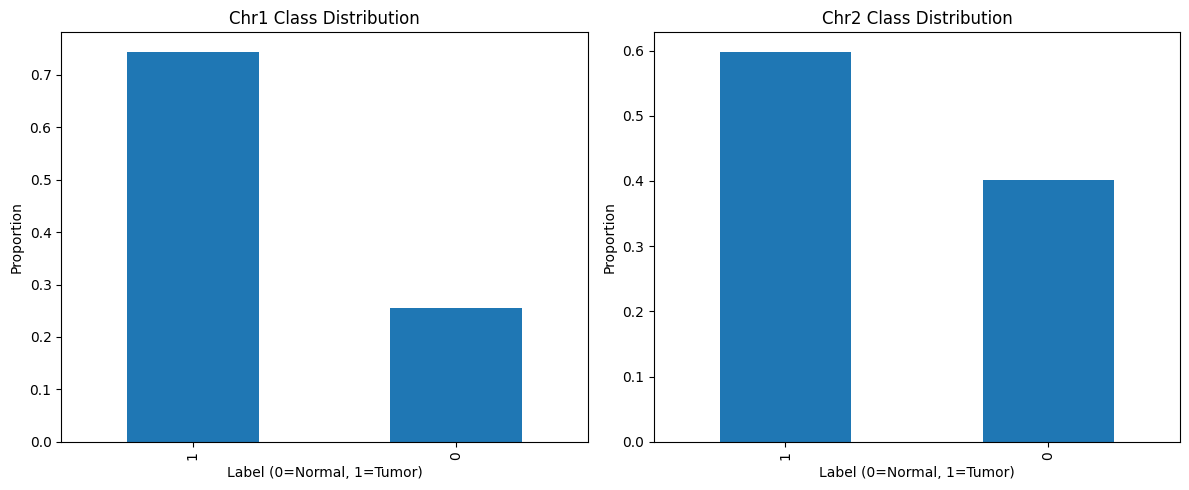


SEQUENCE CHARACTERISTICS ANALYSIS


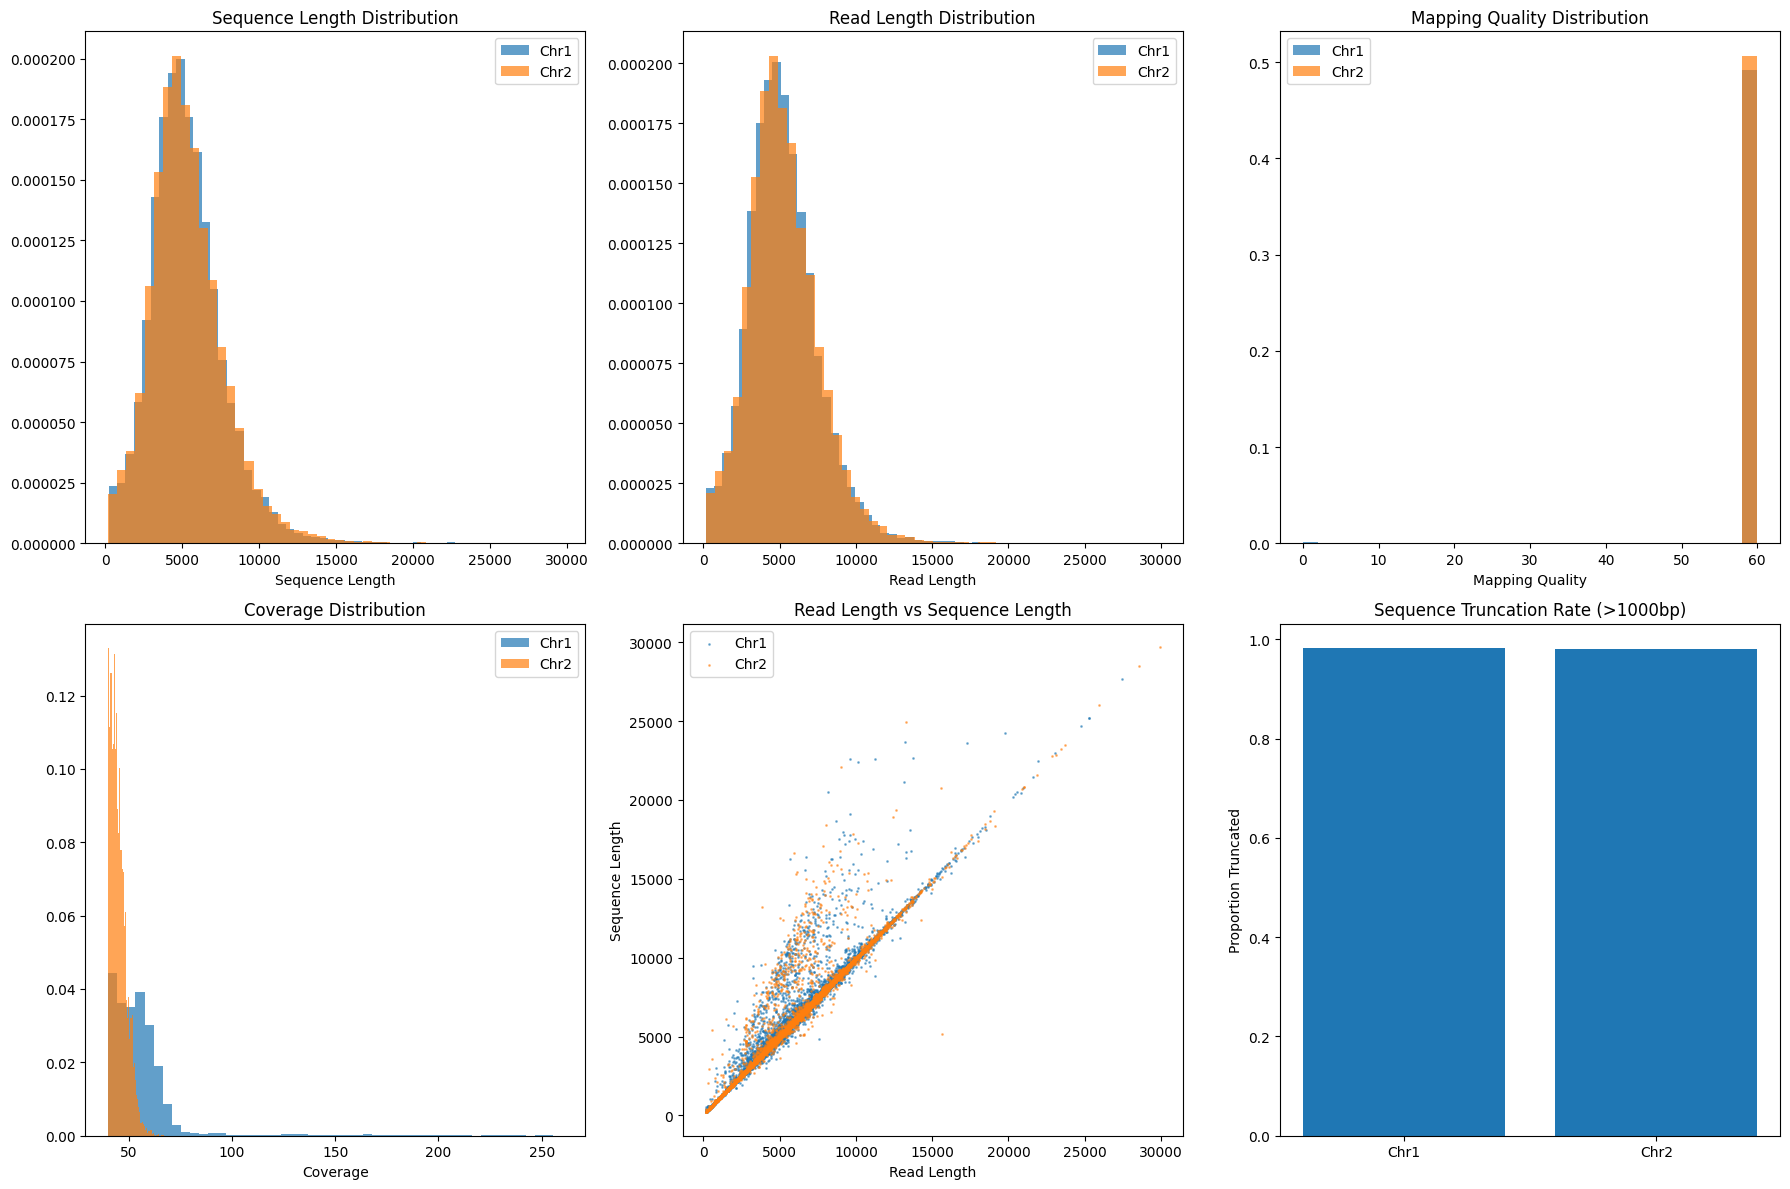

Truncation Analysis:
  Chromosome  Total_Reads  Truncated_Reads  Truncation_Rate
0       Chr1        25098            24644         0.981911
1       Chr2        15637            15340         0.981007

METHYLATION PATTERN ANALYSIS


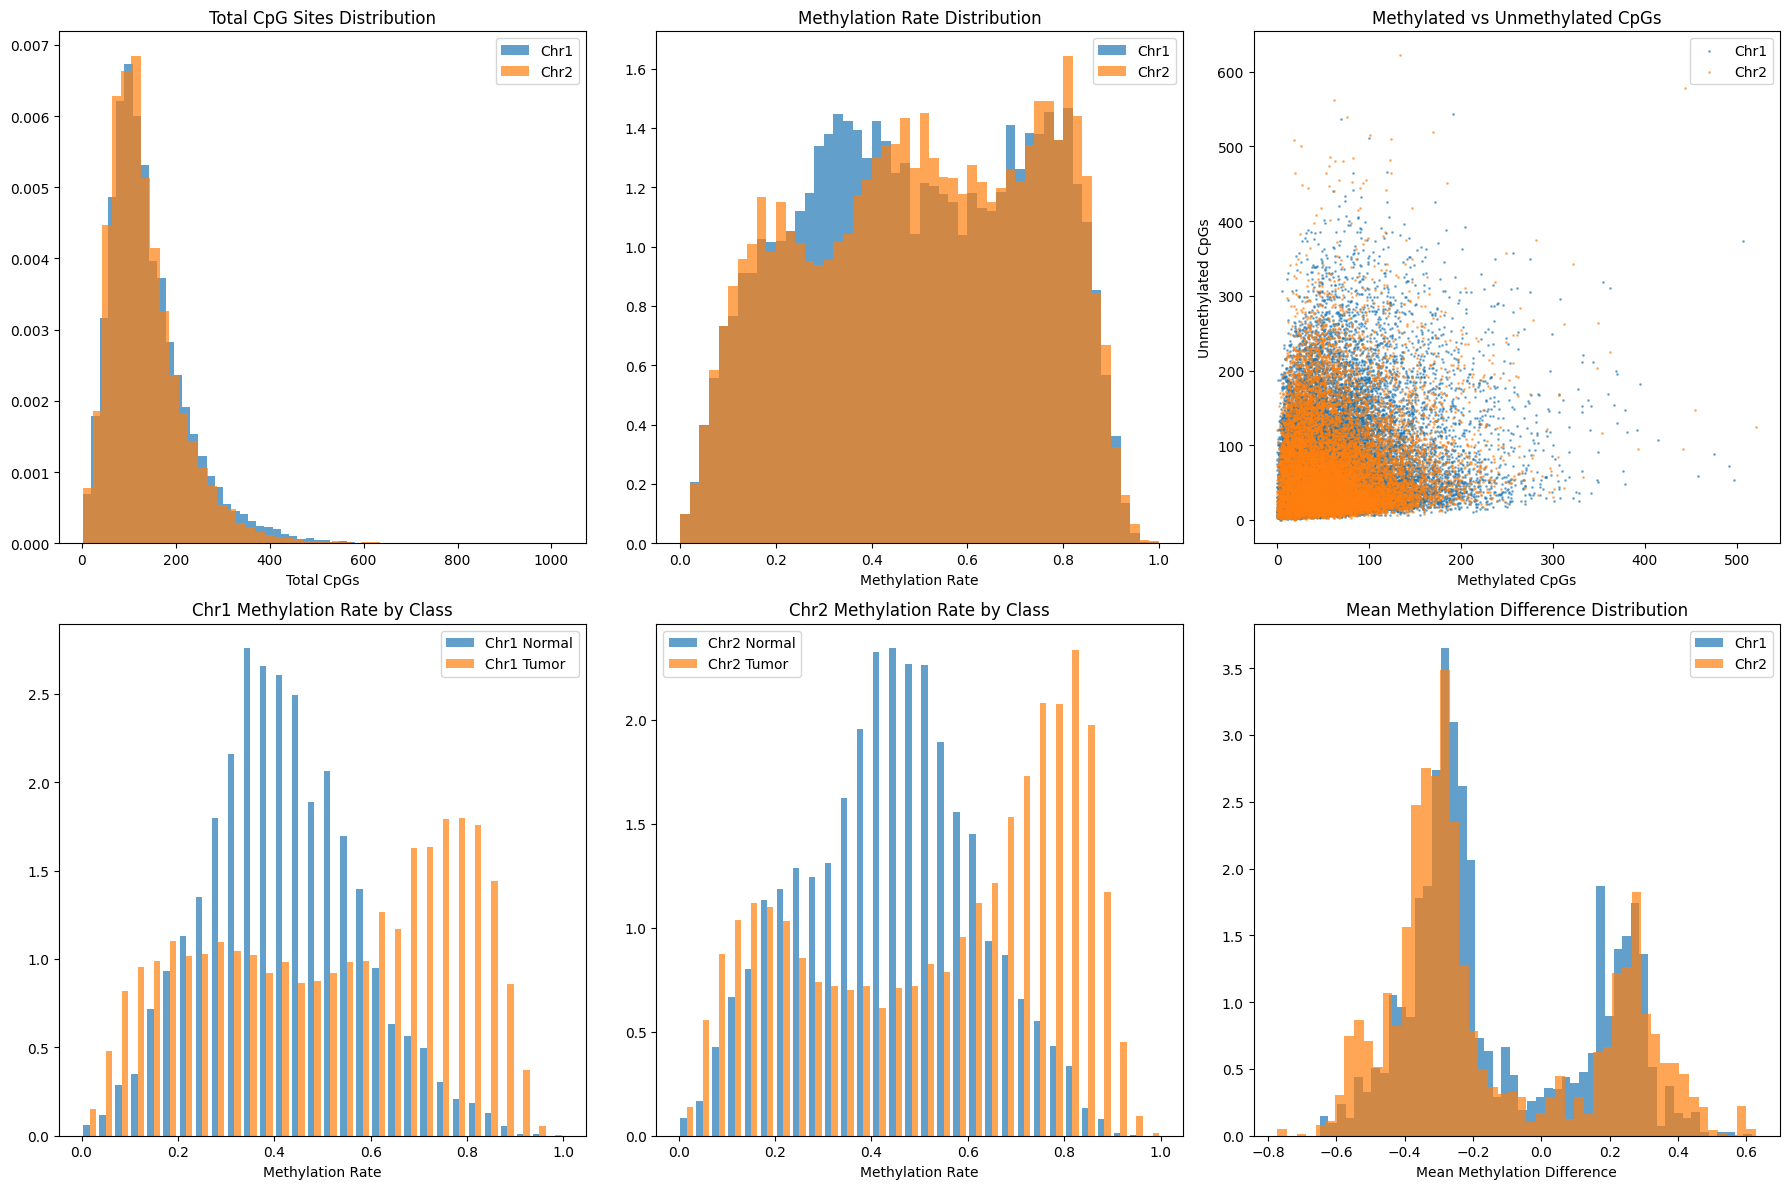

Methylation Rate Statistics:
Chr1 Normal vs Tumor p-value: 2.42e-211
Chr2 Normal vs Tumor p-value: 5.64e-205

DMR CHARACTERISTICS ANALYSIS


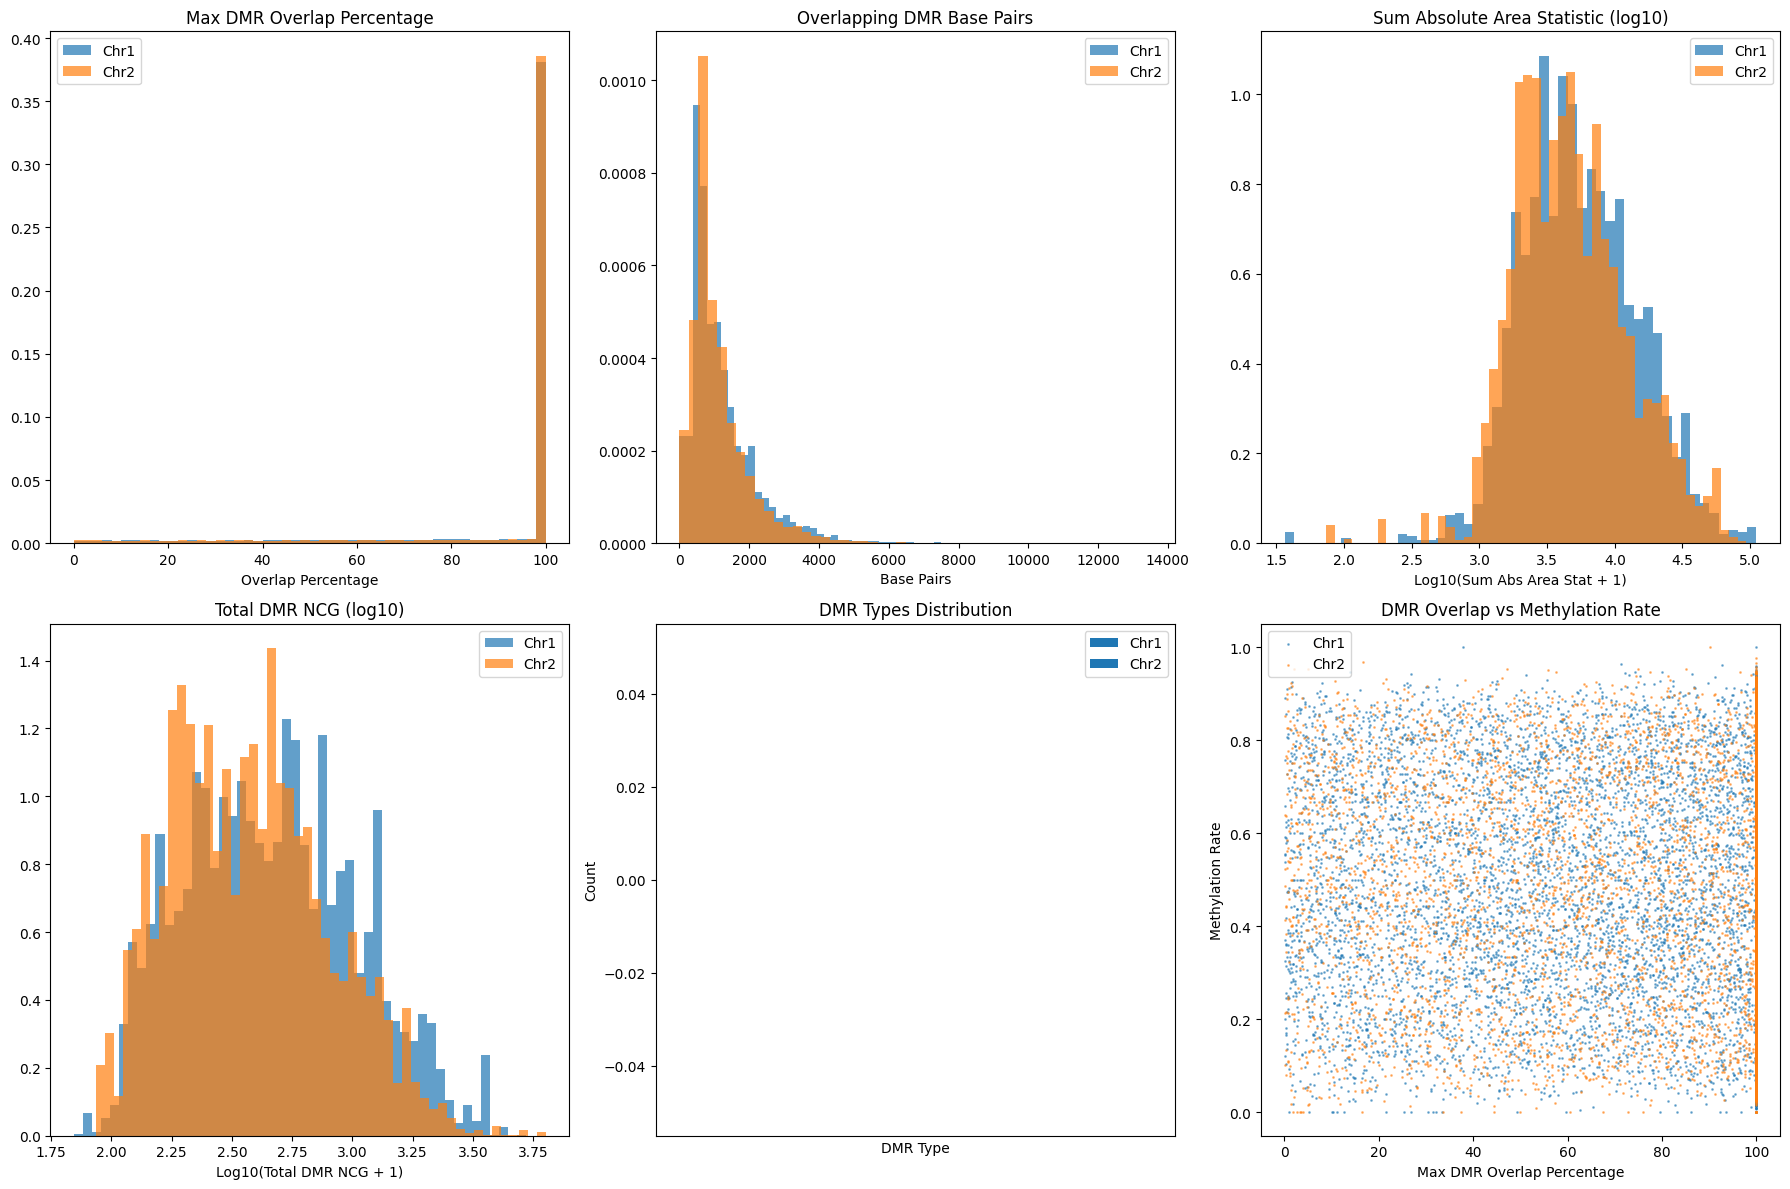

DMR Type Counts:
Chr1: {}
Chr2: {}

FEATURE CORRELATION ANALYSIS
Label correlations with key features:
Chr1:
methylation_rate              0.191038
coverage                      0.179775
methylated_cpgs               0.146444
total_cpgs                    0.047769
unmethylated_cpgs            -0.047747
read_length                   0.045934
mean_methy_diff               0.040944
sequence_length               0.035784
mapping_quality               0.032522
max_dmr_overlap_percentage    0.027842
Name: label, dtype: float64

Chr2:
methylation_rate              0.225141
methylated_cpgs               0.160383
coverage                      0.124266
unmethylated_cpgs            -0.075620
read_length                   0.052568
sequence_length               0.042399
max_dmr_overlap_percentage    0.034974
total_cpgs                    0.032621
overlapping_dmrs_bps          0.022065
total_dmr_ncg                 0.015534
Name: label, dtype: float64

SEQUENCE COMPOSITION ANALYSIS


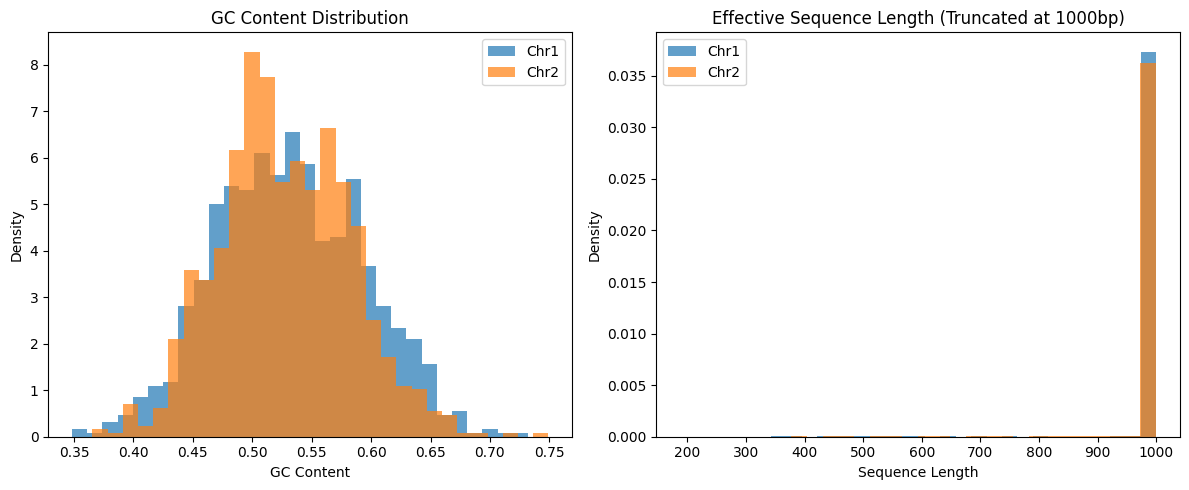

Mean GC content - Chr1: 0.532, Chr2: 0.527
GC content p-value: 1.07e-01

COMPREHENSIVE ANALYSIS SUMMARY
KEY FINDINGS:
1. Dataset sizes: Chr1=25098, Chr2=15637 (ratio: 1.61)
2. Class balance: Chr1=0.256, Chr2=0.402
3. Mean sequence length: Chr1=5315.7, Chr2=5372.4
4. Truncation rate (>1000bp): Chr1=0.982, Chr2=0.981
5. Mean methylation rate: Chr1=0.492, Chr2=0.503
6. Mean DMR overlap: Chr1=88.7%, Chr2=89.0%
7. Mean coverage: Chr1=56.7, Chr2=45.1

POTENTIAL REASONS FOR POOR CHR2 PERFORMANCE:
1. Check if Chr2 has significantly different sequence characteristics
2. Examine class imbalance - Chr2 might have more severe imbalance
3. Analyze if truncation affects Chr2 differently than Chr1
4. Consider chromosome-specific methylation patterns
5. Evaluate if DMR overlap patterns differ substantially
6. Check for potential batch effects or technical differences
7. Consider separate normalization/preprocessing for each chromosome
8. Investigate if model architecture needs chromosome-specific adap

In [21]:
eda = MultiomicsEDA(chr1, chr2)
results = eda.run_complete_analysis()

In [1]:
import os

In [2]:
source = "X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/"
source_normal = source + "normal/"
source_tumor = source + "tumor/"
normal_parquet_files = [source_normal + x for x in os.listdir(source_normal)]
tumour_parquet_files = [source_tumor + x for x in os.listdir(source_tumor)]

In [3]:
normal_parquet_files[4]

'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/normal/COLO829BL_5.bam'

In [77]:
import pyarrow.dataset as ds


def count_parquet_rows(path, chromosome, overlaping_with_dmrs):
    # Load dataset with partitioning
    dataset = ds.dataset(path, format="parquet", partitioning="hive")

    # Now you can filter using partition columns
    filtered_dataset = dataset.filter(
        (ds.field("chromosome") == chromosome)
        & (ds.field("overlapping_with_dmrs") == overlaping_with_dmrs)
        & (ds.field("sequence_length") >= 1000)
    )

    nrows = filtered_dataset.count_rows()
    return nrows

In [83]:
count_parquet_rows(normal_parquet_files[4], "chr16", "false") + count_parquet_rows(
    tumour_parquet_files[4], "chr16", "false"
)

196259

In [76]:
count_parquet_rows(
    "../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/chr16/test_whole_reads.parquet",
    "chr16",
    "true",
)

69513

In [85]:
import pandas as pd

In [92]:
data_original = pd.read_parquet(
    "../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/chr16"
    + "/train.parquet"
)

In [94]:
data_original[data_original["label"] == 1].shape

(88892, 36)

In [96]:
data_original = pd.read_parquet("../Data/Curated/experiment_c/chr19" + "/test.parquet")

In [99]:
data_original[data_original["label"] != 2]

,read_name,original_file,label,input_ids,methylation_ids,read_start,read_end,read_length,sequence_length,total_cpgs,...,mean_methy_diff,total_dmr_ncg,overlap_locations,overlap_names,areastats,prediction,extreme_low,extreme_high,is_extreme,misclassified_extreme
0,335b5489-50ea-4be9-b915-a9cd474608b5,COLO829BL_5.bam,0,CCTCCGGCGCCACAGCAGAAATGGCCAGACGGGCCTGTACCCAAAA...,2222122122222222222222222222202222222222222222...,406122,408698,2576,2576,172,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
1,18a50662-0f4b-4427-8918-57b77ffe8f94,COLO829BL_5.bam,0,AGGCACTCAGTATGGCTGCCTGTGTGCTGGCGTGTGCACGTGTAAG...,2222222222222222222222222222221222222212222222...,406122,408587,2465,2255,94,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
2,babb9551-af71-4063-8e18-8d4f0a41c36f,COLO829BL_5.bam,0,CACGTGAGCCGTGTATGCATGTGTGACCCTGTGTGCGCTTGTGTGT...,2212222221222222222222222222222222212222222222...,406122,407203,1081,1081,38,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
3,b4113721-6817-43b0-a960-8a85c697a268,COLO829BL_5.bam,0,GTATCAAAGAGTGCAGAGGCTGCAGCATTGGGGAGAACAGGGCCTG...,2222222222222222222222222222222222222222222222...,406122,408698,2576,2576,146,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
4,a9394b5d-7597-48bd-bb49-3582a22978b7,COLO829BL_5.bam,0,CTTGACTACATGGATCAGGAAACGGACTCGGACCCCACGGTCCCTG...,2222222222222222222222122222022222222022222222...,406122,408698,2576,2576,177,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,9bf1c238-7588-407e-b4b1-9d96c7205514,COLO829_5.bam,1,TGCTCCGGAACCAGTTCTTGCCCCACCTCACGGACGAACCTCTCGC...,2222212222222222222222222222221222122222222122...,58355864,58357451,1587,1587,158,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
8174,bf3c1e3f-610b-4a5b-af31-9f5e6552692d,COLO829_5.bam,1,CTTCAGTCAGCACTTCATCTCCAGGCAACCACAGGTGACAGTTAAA...,2222222222222222222222222222222222222222222222...,58355864,58356412,548,548,9,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
8175,566b2163-8a3e-413e-95ce-524625b90991,COLO829_5.bam,1,ACACCTGTCGGAGACCCAGTTCTTGCCCACCTCTGCATGGACGAAC...,2222222212222222222222222222222222222222212222...,58355864,58357451,1587,1587,159,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>
8176,c3569b0f-c4af-4896-b482-37a00e37aa60,COLO829_5.bam,1,TGCTGGCGCCTCCTCCTGCTGGGCCGGGCCGGGTGTGGGGATGTGC...,2222220222222222222222221222212222222222222222...,58355864,58357451,1587,1587,136,...,NaN,NaN,None,None,None,NaN,<NA>,<NA>,<NA>,<NA>


In [100]:
count_unique_positions(data_original[data_original["label"] != 2])

np.int64(285144)